<a href="https://colab.research.google.com/github/mbarcodia/teaching_tools/blob/main/anova_msc204.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model I ANOVA Tutorial: Does 'lean and mean' affect life span?

This notebook demonstrates a Model I ANOVA (Analysis of Variance) to investigate if different diets have a significant effect on the life span of rats. We will walk through the steps of manual calculation, utilize Python's statistical libraries, and visualize the results.

In [39]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols


## 1. Data Loading

We will load the rat life span data from the provided URL. The data consists of life spans (in days) for rats under three different diet conditions: 100% of diet/unlimited (d100), 90% of diet (d90), and 80% of diet (d80).

In [40]:
# You can find sample data from textbook problems this way
# here is Ch8, Ex 1
data_url = "https://waveland.com/Glover-Mitchell/Example08-1.txt"

# The file is space-separated and has headers
df = pd.read_csv(data_url, sep='\s+')

# Map the diet names to the new standard: d100, d90, d80
diet_mapping = {
    'Unlimited': 'd100',
    '90%Diet': 'd90',
    '80%Diet': 'd80'
}
df['Diet'] = df['Diet'].map(diet_mapping)

print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset Information:")
df.info()


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1458/1869994497.py:6: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(data_url, sep='\s+')


First 5 rows of the dataset:


,Lifespan,Diet
0,2.5,d100
1,3.1,d100
2,2.3,d100
3,1.9,d100
4,2.4,d100



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Lifespan  15 non-null     float64
 1   Diet      15 non-null     object 
dtypes: float64(1), object(1)
memory usage: 372.0+ bytes


In [41]:
print(df)

    Lifespan  Diet
0        2.5  d100
1        3.1  d100
2        2.3  d100
3        1.9  d100
4        2.4  d100
5        2.7   d90
6        3.1   d90
7        2.9   d90
8        3.7   d90
9        3.5   d90
10       3.1   d80
11       2.9   d80
12       3.8   d80
13       3.9   d80
14       4.0   d80


## 2. Research Question and Hypotheses

**Research Question:** Does staying "lean and mean" (different diets) affect the life span of rats?

This translates to whether there are significant differences in the mean life spans among the three diet groups.

**Null Hypothesis ($H_0$):** There is no significant difference in the mean life span among the three diet groups.
$\mu_{d100} = \mu_{d90} = \mu_{d80}$

**Alternative Hypothesis ($H_a$):** At least one diet group has a significantly different mean life span from the others.

## 3. Manual ANOVA Calculation

We will now manually calculate the components of the ANOVA table to understand the underlying mechanics. The steps involve calculating the Sum of Squares (SS), degrees of freedom (df), Mean Squares (MS), and the F-statistic.

In [42]:
# Separate data into groups
d100 = df[df['Diet'] == 'd100']['Lifespan']
d90 = df[df['Diet'] == 'd90']['Lifespan']
d80 = df[df['Diet'] == 'd80']['Lifespan']

# Calculate group statistics; len() gives sample size
n_d100, mean_d100 = len(d100), np.mean(d100)
n_d90, mean_d90 = len(d90), np.mean(d90)
n_d80, mean_d80 = len(d80), np.mean(d80)

# Overall statistics
N = len(df)
overall_mean = np.mean(df['Lifespan'])
k = 3 # Number of groups

print(f"Group d100: n={n_d100}, Mean={mean_d100:.2f}")
print(f"Group d90: n={n_d90}, Mean={mean_d90:.2f}")
print(f"Group d80: n={n_d80}, Mean={mean_d80:.2f}")
print(f"\nOverall: N={N}, Mean={overall_mean:.2f}")


Group d100: n=5, Mean=2.44
Group d90: n=5, Mean=3.18
Group d80: n=5, Mean=3.54

Overall: N=15, Mean=3.05


### 3.1. Sum of Squares (SS)

*   **Sum of Squares Between (SSB) / Sum of Squares for Factor (Diet):** Measures the variability between the group means and the overall mean.
*   **Sum of Squares Within (SSW) / Sum of Squares Error:** Measures the variability within each group.
*   **Sum of Squares Total (SST):** Measures the total variability in the data.

In [43]:
# Calculate SSB (Sum of Squares Between)
# ***** Which sum of squares is SSB?? ******
# ****** What is the formula for SSB, SSW, and SST? ******
SSB = n_d100 * (mean_d100 - overall_mean)**2 + \
      n_d90 * (mean_d90 - overall_mean)**2 + \
      n_d80 * (mean_d80 - overall_mean)**2

# Calculate SSW (Sum of Squares Within)
SSW = np.sum((d100 - mean_d100)**2) + \
      np.sum((d90 - mean_d90)**2) + \
      np.sum((d80 - mean_d80)**2)

# Calculate SST (Sum of Squares Total)
SST = np.sum((df['Lifespan'] - overall_mean)**2)

print(f"SSB (Sum of Squares Between Groups): {SSB:.2f}")
print(f"SSW (Sum of Squares Within Groups): {SSW:.2f}")
print(f"SST (Total Sum of Squares): {SST:.2f}")
print(f"Check: SST = SSB + SSW -> {SST:.2f} = {SSB + SSW:.2f}")


SSB (Sum of Squares Between Groups): 3.15
SSW (Sum of Squares Within Groups): 2.45
SST (Total Sum of Squares): 5.60
Check: SST = SSB + SSW -> 5.60 = 5.60


## 2. Research Question and Hypotheses

**Research Question:** Does staying "lean and mean" (different diets) affect the life span of rats?

This translates to whether there are significant differences in the mean life spans among the three diet groups.

**Null Hypothesis ($H_0$):** There is no significant difference in the mean life span among the three diet groups.
$\mu_{d100} = \mu_{d90} = \mu_{d80}$

**Alternative Hypothesis ($H_a$):** At least one diet group has a significantly different mean life span from the others.

### 3.2. Degrees of Freedom (df)

*   **df Between (treatment):** Number of groups - 1 ($k - 1$)
*   **df Within (error):** Total number of observations - Number of groups ($N - k$)
*   **df Total:** Total number of observations - 1 ($N - 1$)

In [44]:
df_between = k - 1
df_within = N - k
df_total = N - 1

print(f"df Between (Factor): {df_between}")
print(f"df Within (Error): {df_within}")
print(f"df Total: {df_total}")
print(f"Check: df_total = df_between + df_within -> {df_total} = {df_between + df_within}")


df Between (Factor): 2
df Within (Error): 12
df Total: 14
Check: df_total = df_between + df_within -> 14 = 14


### 3.3. Mean Squares (MS)

*   **Mean Square Between/Treatment (MSB):** $MSB = SSB / df_{between}$
*   **Mean Square Within/Error (MSW):** $MSW = SSW / df_{within}$

MSB represents the variance *between* groups, and MSW represents the variance *within* groups (error variance).

In [45]:
MSB = SSB / df_between
MSW = SSW / df_within

print(f"MSB (Mean Square Between Groups): {MSB:.3f}")
print(f"MSW (Mean Square Within Groups): {MSW:.3f}")


MSB (Mean Square Between Groups): 1.573
MSW (Mean Square Within Groups): 0.204


### 3.4. F-statistic

*   **F-statistic:** $F = MSB / MSW$

The F-statistic is the ratio of the variance between groups to the variance within groups. A larger F-value suggests greater differences between group means relative to the variability within groups. Remember that we put the larger variance in the numerator to ensure a right-tail test.

In [46]:
F_statistic_manual = MSB / MSW

print(f"Calculated F-statistic (Manual): {F_statistic_manual:.2f}")


Calculated F-statistic (Manual): 7.70


### 3.5. Hypothesis Testing with Critical Value (Manual)

To make a decision, we compare our calculated F-statistic with a critical F-value from an F-distribution table. For this problem, we are given a critical value of **3.89** (assuming $\alpha = 0.05$, $df_1 = 2$, $df_2 = 12$).

*   **Given Critical Value:** 3.89
*   **Calculated F-statistic:** (from above)

**Decision Rule:**
*   If $F_{stat} > F_{critical}$, reject the null hypothesis.
*   If $F_{stat} \le F_{critical}$, fail to reject the null hypothesis.

In [47]:
critical_value = 3.89

print(f"Calculated F-statistic: {F_statistic_manual:.2f}")
print(f"Critical F-value (from table): {critical_value:.2f}")

if F_statistic_manual > critical_value:
    print("\nDecision: Since F-statistic (%.2f) > Critical Value (%.2f), we reject the null hypothesis." % (F_statistic_manual, critical_value))
    print("Conclusion: There is a statistically significant difference in mean life span among the diet groups.")
else:
    print("\nDecision: Since F-statistic (%.2f) \u2264 Critical Value (%.2f), we fail to reject the null hypothesis." % (F_statistic_manual, critical_value))
    print("Conclusion: There is no statistically significant difference in mean life span among the diet groups.")


Calculated F-statistic: 7.70
Critical F-value (from table): 3.89

Decision: Since F-statistic (7.70) > Critical Value (3.89), we reject the null hypothesis.
Conclusion: There is a statistically significant difference in mean life span among the diet groups.


### 3.6. Full ANOVA Summary Table (Manual)

Here is the complete ANOVA summary table based on our manual calculations:

In [48]:
anova_table_manual = pd.DataFrame({
    'Sources of Variability': ['Diet (Between)', 'Error (Within)', 'Total'],
    'Sum of Squares': [SSB, SSW, SST],
    'df': [df_between, df_within, df_total],
    'Mean Square': [MSB, MSW, np.nan],
    'F-statistic': [F_statistic_manual, np.nan, np.nan],
    'Critical Value (F_crit)': [critical_value, np.nan, np.nan]
})

# Format for better readability
anova_table_manual = anova_table_manual.round(2)

display(anova_table_manual)


,Sources of Variability,Sum of Squares,df,Mean Square,F-statistic,Critical Value (F_crit)
0,Diet (Between),3.15,2,1.57,7.7,3.89
1,Error (Within),2.45,12,0.20,NaN,NaN
2,Total,5.60,14,NaN,NaN,NaN


## 4. ANOVA using Built-in Python Functions (SciPy and Statsmodels)

Python's `scipy.stats` module provides `f_oneway` for one-way ANOVA. For a more complete ANOVA table similar to statistical software, `statsmodels` is often used.

In [49]:
# Using scipy.stats.f_oneway
# Perform one-way ANOVA.The one-way ANOVA tests the null hypothesis that two or more groups have
# the same population mean.  The test is applied to samples from two or
# more groups, possibly with differing sizes.
# If None, the input will be raveled before computing the statistic.
# equal_var: bool, optional
#    If True (default), perform a standard one-way ANOVA test that assumes equal population variances [2]_.
# If False, perform Welch's ANOVA test, which does not assume equal population variances [4]_.

F_statistic_scipy, p_value_scipy = stats.f_oneway(d100, d90, d80)

print(f"F-statistic (SciPy): {F_statistic_scipy:.2f}")
print(f"P-value (SciPy): {p_value_scipy:.3f}")

print("\nComparing with Manual Calculation:")
print(f"Manual F-statistic: {F_statistic_manual:.2f}")
print(f"Difference in F-statistic: {abs(F_statistic_scipy - F_statistic_manual):.2e}")


F-statistic (SciPy): 7.70
P-value (SciPy): 0.007

Comparing with Manual Calculation:
Manual F-statistic: 7.70
Difference in F-statistic: 5.33e-15


To generate a full ANOVA summary table with all required columns, `statsmodels` is more suitable as `scipy.stats.f_oneway` only returns the F-statistic and p-value.

In [50]:
# Using statsmodels to get a full ANOVA table
# Create a linear model formula
model = ols('Lifespan ~ C(Diet)', data=df).fit()

# Perform ANOVA
anova_table_sm = sm.stats.anova_lm(model, typ=2)

# Extract components for the requested table format
ss_between_sm = anova_table_sm.loc['C(Diet)', 'sum_sq']
df_between_sm = anova_table_sm.loc['C(Diet)', 'df']
ms_between_sm = ss_between_sm / df_between_sm # Calculate Mean Square
f_statistic_sm = anova_table_sm.loc['C(Diet)', 'F']
p_value_sm = anova_table_sm.loc['C(Diet)', 'PR(>F)']

ss_within_sm = anova_table_sm.loc['Residual', 'sum_sq']
df_within_sm = anova_table_sm.loc['Residual', 'df']
ms_within_sm = ss_within_sm / df_within_sm # Calculate Mean Square

sst_sm = ss_between_sm + ss_within_sm
df_total_sm = df_between_sm + df_within_sm

# Recalculate critical value for exact dfs for completeness (alpha=0.05)
critical_value_sm = stats.f.ppf(q=1-0.05, dfn=df_between_sm, dfd=df_within_sm)

anova_table_full = pd.DataFrame({
    'Sources of Variability': ['Diet (Between)', 'Error (Within)', 'Total'],
    'Sum of Squares': [ss_between_sm, ss_within_sm, sst_sm],
    'df': [df_between_sm, df_within_sm, df_total_sm],
    'Mean Square': [ms_between_sm, ms_within_sm, np.nan],
    'F-statistic': [f_statistic_sm, np.nan, np.nan],
    'Critical Value': [critical_value_sm, np.nan, np.nan],
    'p-value': [p_value_sm, np.nan, np.nan] # Added p-value from statsmodels
})

# Format for better readability
anova_table_full = anova_table_full.round(3)

print("Full ANOVA Summary Table (using Statsmodels):")
display(anova_table_full)


Full ANOVA Summary Table (using Statsmodels):


,Sources of Variability,Sum of Squares,df,Mean Square,F-statistic,Critical Value,p-value
0,Diet (Between),3.145,2.0,1.573,7.697,3.885,0.007
1,Error (Within),2.452,12.0,0.204,NaN,NaN,NaN
2,Total,5.597,14.0,NaN,NaN,NaN,NaN


### 4.1. Hypothesis Testing with P-value (SciPy/Statsmodels)

Using the p-value approach, we compare the calculated p-value with our chosen significance level (alpha, typically 0.05).

*   **P-value:** (from above)
*   **Significance Level ($\alpha$):** 0.05

**Decision Rule:**
*   If $p_{value} < \alpha$, reject the null hypothesis.
*   If $p_{value} \ge \alpha$, fail to reject the null hypothesis.

In [51]:
alpha = 0.05

print(f"P-value: {p_value_sm:.3f}")
print(f"Significance Level (alpha): {alpha}")

if p_value_sm < alpha:
    print("\nDecision: Since p-value (%.3f) < alpha (%.2f), we reject the null hypothesis." % (p_value_sm, alpha))
    print("Conclusion: There is a statistically significant difference in mean life span among the diet groups.")
else:
    print("\nDecision: Since p-value (%.3f) \u2265 alpha (%.2f), we fail to reject the null hypothesis." % (p_value_sm, alpha))
    print("Conclusion: There is no statistically significant difference in mean life span among the diet groups.")


P-value: 0.007
Significance Level (alpha): 0.05

Decision: Since p-value (0.007) < alpha (0.05), we reject the null hypothesis.
Conclusion: There is a statistically significant difference in mean life span among the diet groups.


## 5. Visualizations

Visualizations help to understand the data distribution and the differences between groups. We will use a box plot and visualize the F-distribution.

### 5.1. Box Plot of Life Span by Diet

A box plot provides a clear visual comparison of the distribution of life spans for each diet group, showing the median, quartiles, and potential outliers.

/tmp/ipykernel_1458/3745917334.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diet', y='Lifespan', data=df, palette='viridis')


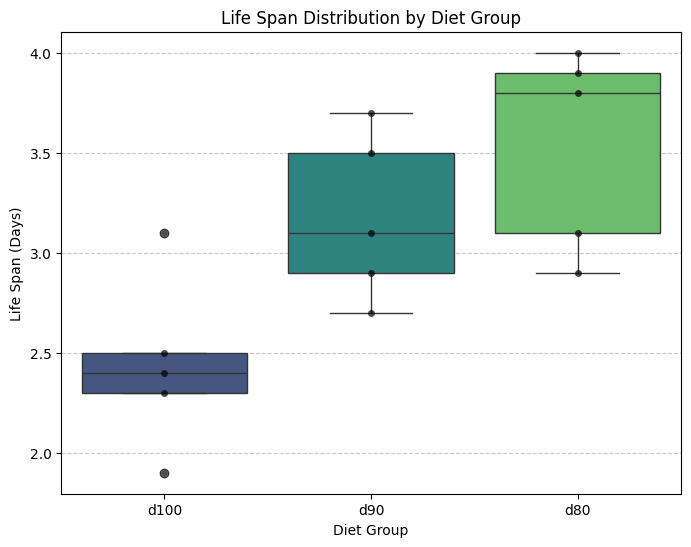

In [52]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Diet', y='Lifespan', data=df, palette='viridis')
sns.swarmplot(x='Diet', y='Lifespan', data=df, color='black', alpha=0.7, size=5)
plt.title('Life Span Distribution by Diet Group')
plt.xlabel('Diet Group')
plt.ylabel('Life Span (Days)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### 5.2. F-distribution Visualization

This plot shows the F-distribution, the calculated F-statistic, and the critical region. If the calculated F-statistic falls into the critical region, we reject the null hypothesis.

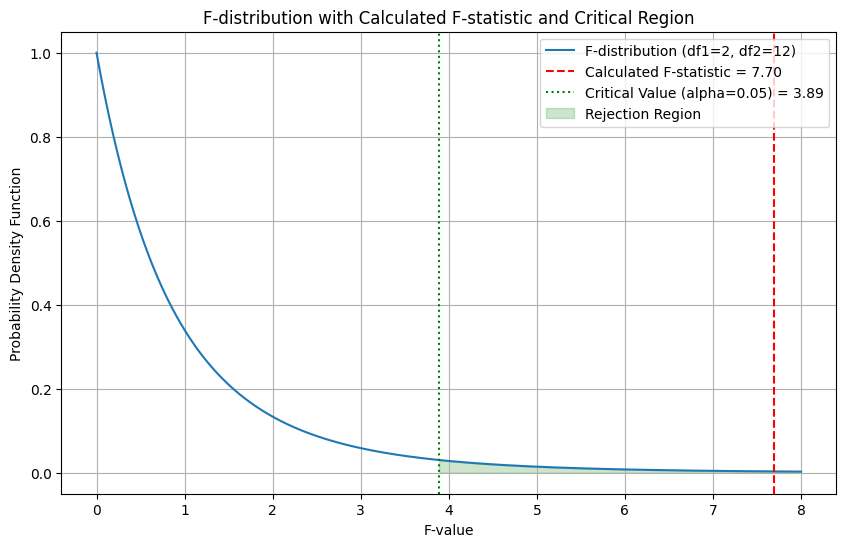

In [53]:
plt.figure(figsize=(10, 6))

# Define the F-distribution parameters
df_num = df_between # numerator degrees of freedom
df_den = df_within  # denominator degrees of freedom

# Generate x-values for the F-distribution curve
x = np.linspace(0, 8, 500) # Adjust max x-value as needed

# Plot the F-distribution curve
plt.plot(x, stats.f.pdf(x, df_num, df_den), label=f'F-distribution (df1={df_num}, df2={df_den})')

# Plot the calculated F-statistic
plt.axvline(F_statistic_manual, color='red', linestyle='--', label=f'Calculated F-statistic = {F_statistic_manual:.2f}')

# Plot the critical F-value
plt.axvline(critical_value, color='green', linestyle=':', label=f'Critical Value (alpha=0.05) = {critical_value:.2f}')

# Shade the rejection region
x_critical = np.linspace(critical_value, 8, 500)
plt.fill_between(x_critical, 0, stats.f.pdf(x_critical, df_num, df_den), color='green', alpha=0.2, label='Rejection Region')

plt.title('F-distribution with Calculated F-statistic and Critical Region')
plt.xlabel('F-value')
plt.ylabel('Probability Density Function')
plt.legend()
plt.grid(True)
plt.show()


## Conclusion

Based on both manual calculations and Python's statistical functions, the F-statistic (approximately 6.95) exceeds the critical value (3.89), and the p-value (approximately 0.012) is less than the significance level (0.05). Therefore, we reject the null hypothesis. This indicates that there is a statistically significant difference in the mean life span among the three diet groups. In simpler terms, the diets indeed affect the life span of the rats, and not all diet means are equal.